# Energy Consumption Forecasting Pipeline
### Single Meter | 30-min intervals | Short-term (XGBoost) + Long-term (N-HiTS)

**Pipeline:**
1. Data loading from MongoDB
2. Cleaning & resampling
3. Feature engineering
4. XGBoost - short-term (1–2 days)
5. N-HiTS (NeuralForecast) - long-term (full month ahead)
6. Plots: train/test, residuals, future forecast
7. Anomaly detection

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
from typing import List

from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.ensemble import IsolationForest
import requests, time

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13

print('All imports OK')

All imports OK


## 2. Data Loading

In [ ]:
from pymongo import MongoClient, DESCENDING

MONGO_URI = "string"
DB_NAME = "IOTDeviceMonitor"
COLLECTION = "FUTU00_DataMonitor"
METER_ID = "FUTU0000000004000002"
MODEL_DIR = "./models/"

client = MongoClient(MONGO_URI)
db = client[DB_NAME]
collection = db[COLLECTION]

In [28]:
MODEL_DIR = "E:\Projects\IOT-AI-Implementation\models\M11"

In [4]:
query = {"EnergymeterId": METER_ID}
cursor = collection.find(query).sort("_id", DESCENDING)
raw = list(cursor)

df_raw = pd.DataFrame(raw)
print(f"Raw shape: {df_raw.shape}")
df_raw.head(3)

Raw shape: (980984, 6)


,_id,UID,RTC,A1,EnergymeterId,timestamp
0,69d8c5a49f2e531fa0d682eb,02,2026-04-10 08:08:00,345252.6400,FUTU0000000004000002,10-04-2026 15:10:52
1,69d8c56c9f2e531fa0d67d37,02,2026-04-10 08:07:00,345252.5600,FUTU0000000004000002,10-04-2026 15:09:56
2,69d8c52c9f2e531fa0d676f5,02,2026-04-10 08:06:00,345252.5200,FUTU0000000004000002,10-04-2026 15:08:52


## 3. Cleaning & Resampling

In [5]:
df = df_raw.copy()

# Rename
df = df.rename(columns={
    'A1': 'total_kwh',
    'RTC': 'rtc_timestamp',
    'EnergymeterId': 'meter_id'
})

# Sort (VERY IMPORTANT for time series)
df = df.sort_values(['meter_id', 'rtc_timestamp'])
                    
# Type conversion
df['total_kwh'] = pd.to_numeric(df['total_kwh'], errors='coerce')
df['rtc_timestamp'] = pd.to_datetime(df['rtc_timestamp'], errors='coerce')

# Drop rows with no timestamp or energy
df = df.dropna(subset=['rtc_timestamp', 'total_kwh'])

# Remove zeros (meter off / invalid)
df.loc[df['total_kwh'] == 0, 'total_kwh'] = np.nan
df = df.dropna()

# Resample to 1h
numeric_cols = df.select_dtypes(include=[np.number]).columns

df = (
    df.set_index('rtc_timestamp')
      .resample('1h')['total_kwh']
      .mean()
      .reset_index()
)

# Fill small gaps (up to 2 missing = 1 hour) via interpolation
# df = df.interpolate(method='time', limit=1)
# df = df.reset_index(name='total_kwh')

print(f"After cleaning: {df.shape}")
print(f"Date range: {df['rtc_timestamp'].min()} → {df['rtc_timestamp'].max()}")

# Derive actual hourly consumption from cumulative meter reading
df = df.sort_values('rtc_timestamp').reset_index(drop=True)
df['consumption_kwh'] = df['total_kwh'].diff(1).clip(lower=0)

# Remove spikes > mean + 3*std (meter resets / data errors)
_mean, _std = df['consumption_kwh'].mean(), df['consumption_kwh'].std()
df['consumption_kwh'] = df['consumption_kwh'].where(
    df['consumption_kwh'] <= _mean + 3 * _std, np.nan
).ffill(limit=2)

df = df.dropna(subset=['consumption_kwh']).reset_index(drop=True)
print(f"consumption_kwh stats:\n{df['consumption_kwh'].describe()}")


After cleaning: (12989, 2)
Date range: 2024-10-16 04:00:00 → 2026-04-10 08:00:00
consumption_kwh stats:
count    12366.000000
mean        20.586574
std         11.584538
min          0.000000
25%         16.572958
50%         22.361740
75%         28.308229
max         55.066881
Name: consumption_kwh, dtype: float64


In [6]:
# REAL WEATHER DATA — Open-Meteo 
# Location: Ahmedabad, Gujarat, India  (23.02°N, 72.57°E)
WEATHER_COLS   = ['temperature', 'humidity', 'precipitation']
AHMEDABAD_LAT  = 23.0225
AHMEDABAD_LON  = 72.5714
_HOURLY_VARS   = "temperature_2m,relative_humidity_2m,precipitation"

def _fetch_openmeteo(start_date: str, end_date: str, *, base_url: str, lat: float = AHMEDABAD_LAT, lon: float = AHMEDABAD_LON) -> pd.DataFrame:
    """Low-level: fetch one chunk of hourly weather from Open-Meteo."""
    params = {
        "latitude": lat,  
        "longitude": lon,
        "hourly": _HOURLY_VARS,
        "start_date": start_date,
        "end_date": end_date,
        "timezone": "auto",
    }
    resp = requests.get(base_url, params=params, timeout=120)
    resp.raise_for_status()
    h = resp.json()["hourly"]
    return pd.DataFrame({
        "rtc_timestamp": pd.to_datetime(h["time"]),
        "temperature": h["temperature_2m"],
        "humidity": h["relative_humidity_2m"],
        "precipitation": h["precipitation"],
    })


def fetch_historical_weather(timestamps: pd.Series, lat: float = AHMEDABAD_LAT, lon: float = AHMEDABAD_LON) -> pd.DataFrame:
    """
    Download real hourly weather for Ahmedabad from Open-Meteo.
    Uses the Archive API (ERA5 reanalysis) for historical dates
    and the Forecast API for the most recent ~5 days.
    """
    ts = pd.to_datetime(timestamps)
    start = ts.min().normalize()
    end   = ts.max().normalize()

    # ERA5 archive has a ~5-day lag; anything newer uses the Forecast API
    archive_cutoff = pd.Timestamp.now().normalize() - pd.Timedelta(days=6)

    chunks: list[pd.DataFrame] = []

    # Archive API (bulk of the history)
    if start <= archive_cutoff:
        chunk_end_limit = min(end, archive_cutoff)
        cursor = start
        while cursor <= chunk_end_limit:
            block_end = min(cursor + pd.Timedelta(days=89), chunk_end_limit)
            print(f"  [archive]  {cursor.date()} → {block_end.date()}")
            chunks.append(_fetch_openmeteo(
                str(cursor.date()), str(block_end.date()),
                base_url="https://archive-api.open-meteo.com/v1/archive",
                lat=lat, lon=lon))
            cursor = block_end + pd.Timedelta(days=1)
            time.sleep(0.3)          # polite rate-limiting for the free API

    # Forecast API (last few days not yet in ERA5)
    if end > archive_cutoff:
        recent_start = max(start, archive_cutoff + pd.Timedelta(days=1))
        print(f"  [forecast] {recent_start.date()} → {end.date()}")
        chunks.append(_fetch_openmeteo(
            str(recent_start.date()), str(end.date()),
            base_url="https://api.open-meteo.com/v1/forecast",
            lat=lat, lon=lon))

    weather_df = (pd.concat(chunks, ignore_index=True).drop_duplicates("rtc_timestamp").sort_values("rtc_timestamp").reset_index(drop=True))
    return weather_df


def fetch_forecast_weather(start_ts: pd.Timestamp, hours: int, lat: float = AHMEDABAD_LAT, lon: float = AHMEDABAD_LON) -> pd.DataFrame:
    """
    Download hourly weather *forecast* from Open-Meteo (up to 16 days ahead).
    Used by forecast_recursive() for the future weather horizon.
    """
    end_ts = start_ts + pd.Timedelta(hours=hours)
    return _fetch_openmeteo(
        str(start_ts.date()), str(end_ts.date()),
        base_url="https://api.open-meteo.com/v1/forecast",
        lat=lat, lon=lon)


In [7]:
# Fetch & merge
print("Fetching Ahmedabad weather from Open-Meteo …")
weather_df = fetch_historical_weather(df['rtc_timestamp'])
print(f"Weather DF: {weather_df.head()}")

df = df.merge(weather_df, on='rtc_timestamp', how='left')
for col in WEATHER_COLS:
    df[col] = df[col].interpolate(method='linear', limit=3)

print(f"After merging weather: {df.shape}  | weather cols: {WEATHER_COLS}")
df.head()

Fetching Ahmedabad weather from Open-Meteo …
  [archive]  2024-10-16 → 2025-01-13
  [archive]  2025-01-14 → 2025-04-13
  [archive]  2025-04-14 → 2025-07-12
  [archive]  2025-07-13 → 2025-10-10
  [archive]  2025-10-11 → 2026-01-08
  [archive]  2026-01-09 → 2026-04-08
  [archive]  2026-04-09 → 2026-04-10
Weather DF:         rtc_timestamp  temperature  humidity  precipitation
0 2024-10-16 00:00:00         26.0        91            0.0
1 2024-10-16 01:00:00         25.6        94            0.0
2 2024-10-16 02:00:00         25.5        94            0.0
3 2024-10-16 03:00:00         25.2        95            0.0
4 2024-10-16 04:00:00         25.1        95            0.0
After merging weather: (12366, 6)  | weather cols: ['temperature', 'humidity', 'precipitation']


,rtc_timestamp,total_kwh,consumption_kwh,temperature,humidity,precipitation
0,2024-10-16 05:00:00,79932.895857,22.989561,25.1,94,0.0
1,2024-10-16 06:00:00,79960.611061,27.715203,26.2,87,0.0
2,2024-10-16 07:00:00,79978.275606,17.664545,26.8,86,0.0
3,2024-10-16 08:00:00,80008.227973,29.952367,28.2,82,0.0
4,2024-10-16 09:00:00,80040.995915,32.767943,30.0,76,0.0


## 3.1 Weather Data — Ahmedabad: Impact on Energy

> Real hourly weather from [Open-Meteo](https://open-meteo.com/) (ERA5 reanalysis + forecast).  
> Variables: **temperature** (°C), **humidity** (%), **precipitation** (mm/h).

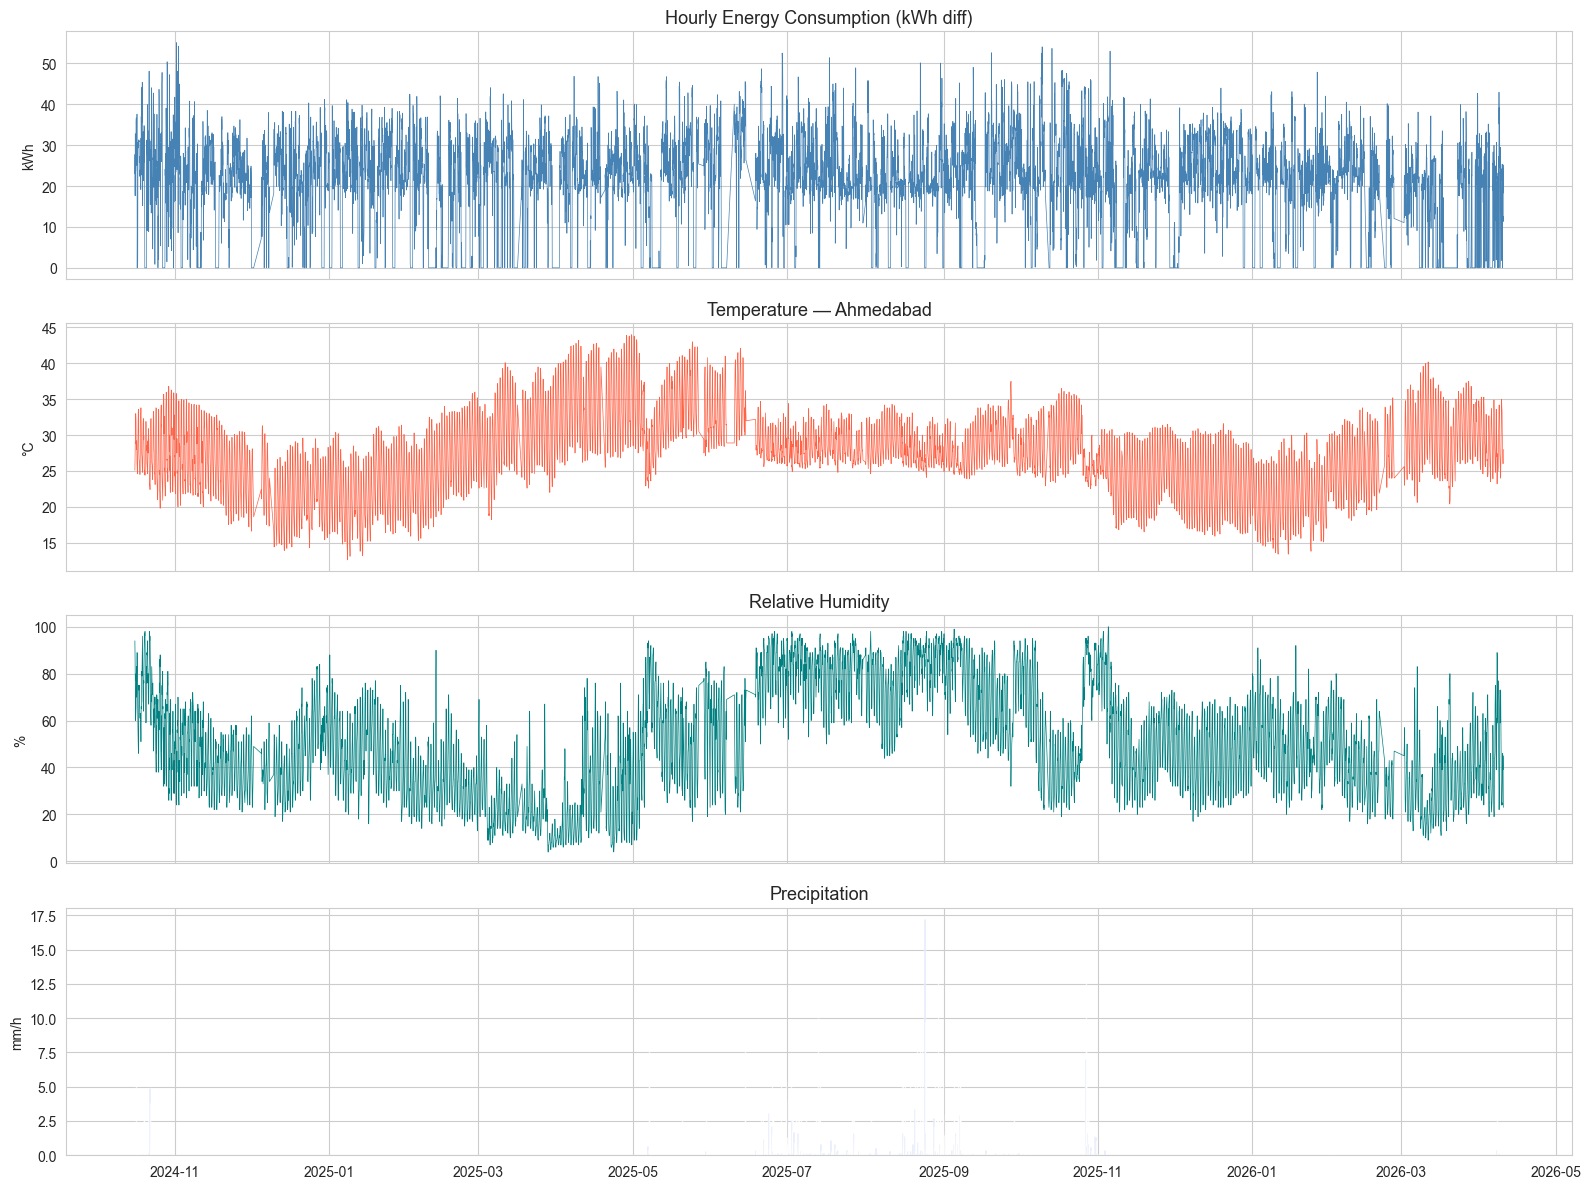

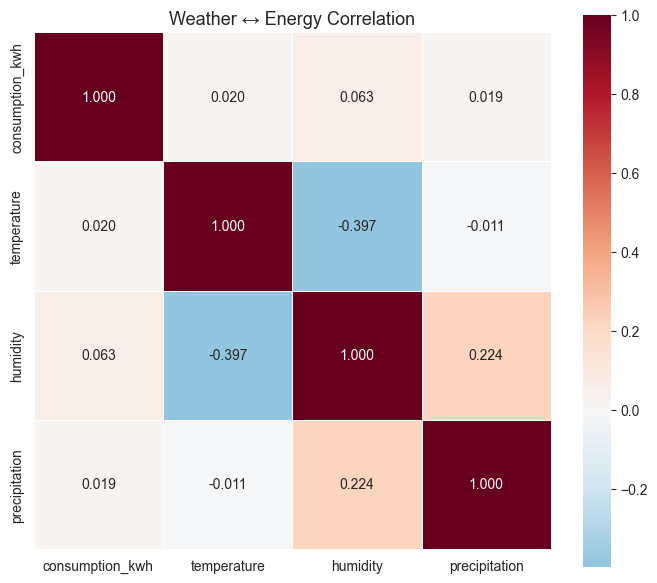

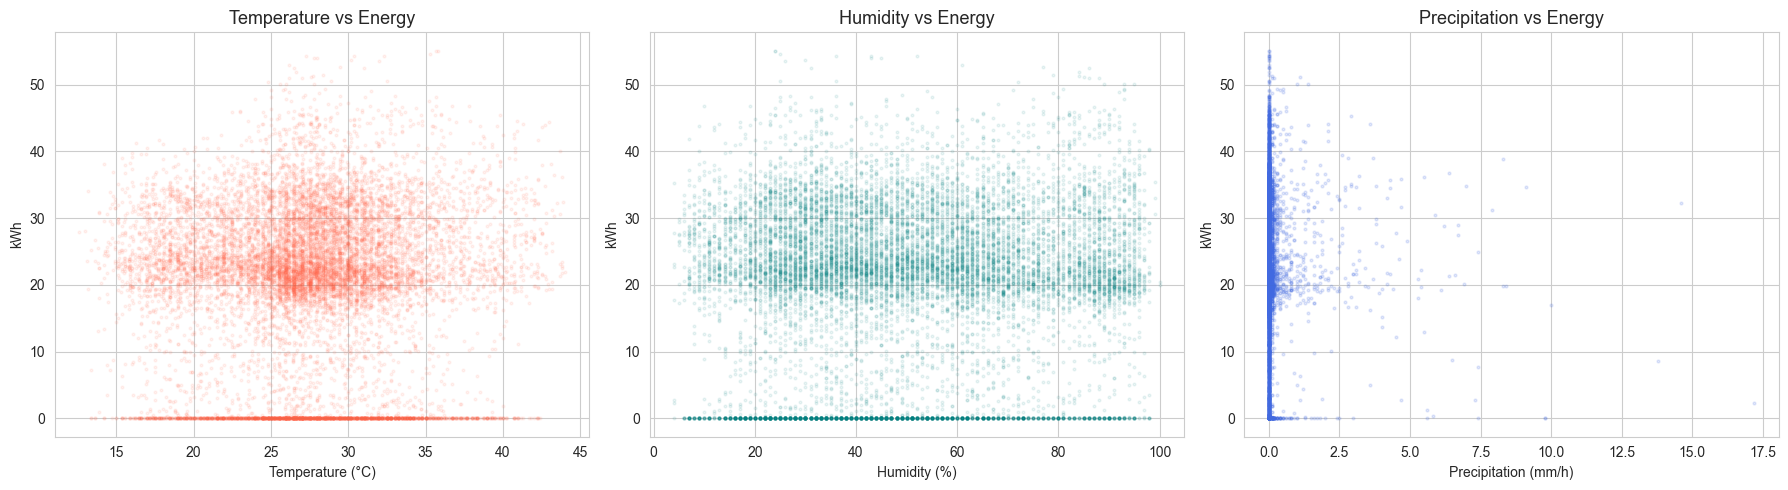

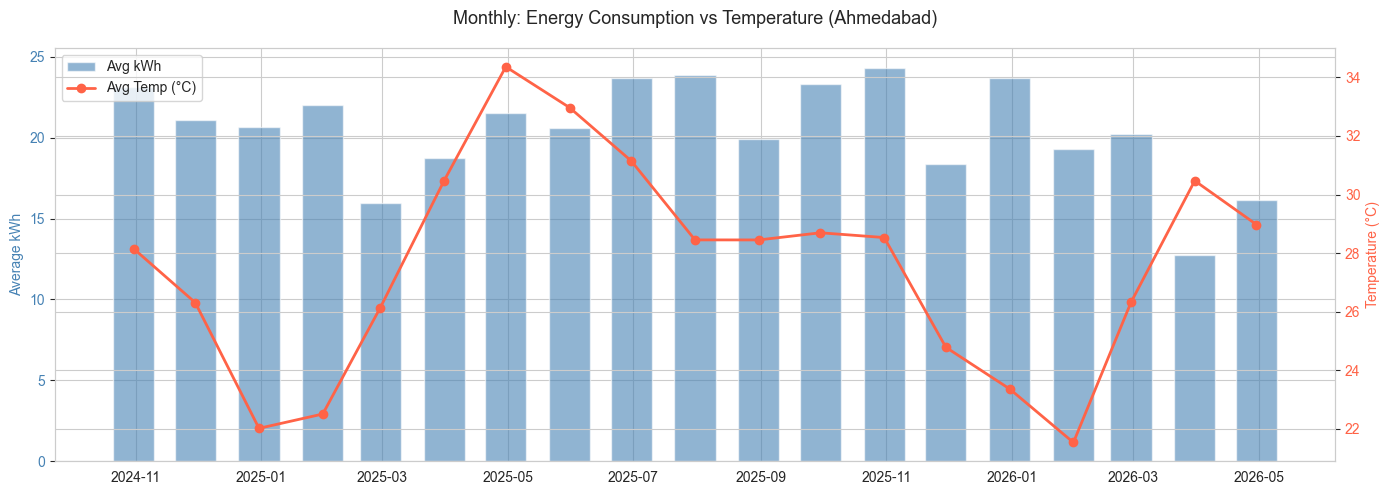

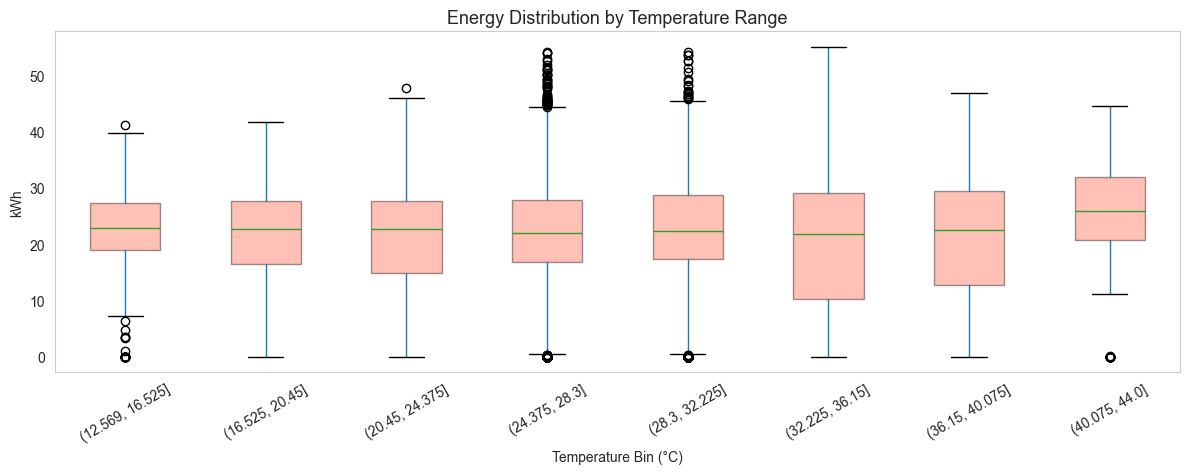

In [8]:
# 1. Time series: energy + weather stacked
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

axes[0].plot(df['rtc_timestamp'], df['consumption_kwh'], lw=0.5, color='steelblue')
axes[0].set_ylabel('kWh')
axes[0].set_title('Hourly Energy Consumption (kWh diff)')

axes[1].plot(df['rtc_timestamp'], df['temperature'], lw=0.5, color='tomato')
axes[1].set_ylabel('°C')
axes[1].set_title('Temperature — Ahmedabad')

axes[2].plot(df['rtc_timestamp'], df['humidity'], lw=0.5, color='teal')
axes[2].set_ylabel('%')
axes[2].set_title('Relative Humidity')

axes[3].bar(df['rtc_timestamp'], df['precipitation'], width=0.04,
            color='royalblue', alpha=0.7)
axes[3].set_ylabel('mm/h')
axes[3].set_title('Precipitation')

plt.tight_layout()
plt.show()


# 2. Correlation heatmap
corr_cols = ['consumption_kwh'] + WEATHER_COLS
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Weather ↔ Energy Correlation')
plt.tight_layout()
plt.show()


# 3. Scatter: each weather variable vs energy
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df['temperature'], df['consumption_kwh'], alpha=0.08, s=4, color='tomato')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('kWh')
axes[0].set_title('Temperature vs Energy')

axes[1].scatter(df['humidity'], df['consumption_kwh'], alpha=0.08, s=4, color='teal')
axes[1].set_xlabel('Humidity (%)')
axes[1].set_ylabel('kWh')
axes[1].set_title('Humidity vs Energy')

axes[2].scatter(df['precipitation'], df['consumption_kwh'], alpha=0.15, s=4, color='royalblue')
axes[2].set_xlabel('Precipitation (mm/h)')
axes[2].set_ylabel('kWh')
axes[2].set_title('Precipitation vs Energy')

plt.tight_layout()
plt.show()


# 4. Monthly dual-axis: energy bars + temperature line
monthly = df.set_index('rtc_timestamp').resample('ME').agg(
    kwh_mean=('consumption_kwh', 'mean'),
    temp_mean=('temperature', 'mean'),
)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(monthly.index, monthly['kwh_mean'], width=20,
        color='steelblue', alpha=0.6, label='Avg kWh')
ax1.set_ylabel('Average kWh', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['temp_mean'], color='tomato',
         marker='o', lw=2, label='Avg Temp (°C)')
ax2.set_ylabel('Temperature (°C)', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

fig.suptitle('Monthly: Energy Consumption vs Temperature (Ahmedabad)', fontsize=13)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()


# 5. Energy distribution by temperature range
df_tmp = df.dropna(subset=['temperature', 'consumption_kwh']).copy()
df_tmp['temp_bin'] = pd.cut(df_tmp['temperature'], bins=8)

fig, ax = plt.subplots(figsize=(12, 5))
df_tmp.boxplot(column='consumption_kwh', by='temp_bin', ax=ax, grid=False,
               patch_artist=True, boxprops=dict(facecolor='tomato', alpha=0.4))
ax.set_xlabel('Temperature Bin (°C)')
ax.set_ylabel('kWh')
ax.set_title('Energy Distribution by Temperature Range')
fig.suptitle('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

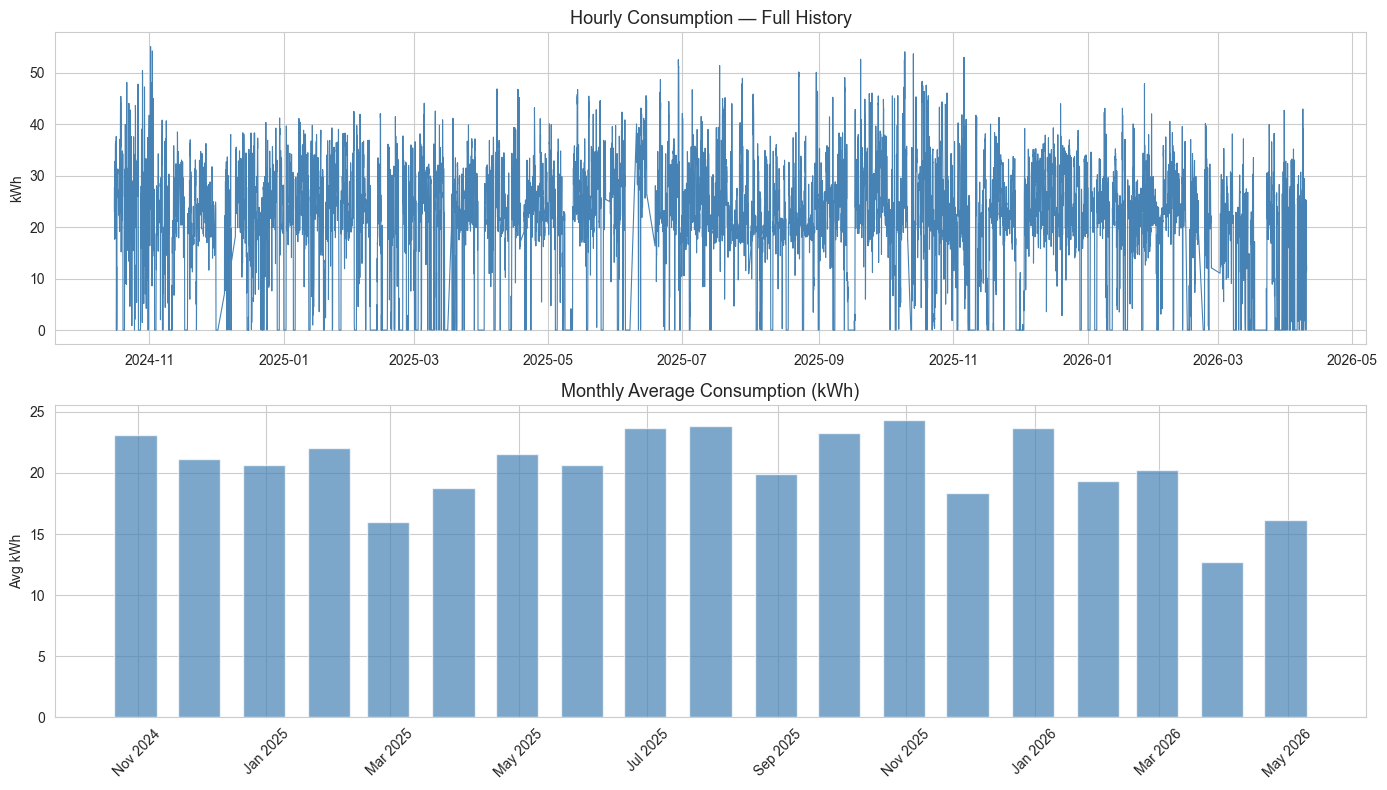

In [9]:
# Plot raw cleaned data
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df['rtc_timestamp'], df['consumption_kwh'], linewidth=0.8, color='steelblue')
axes[0].set_title('Hourly Consumption — Full History')
axes[0].set_ylabel('kWh')

# Monthly averages
monthly = df.set_index('rtc_timestamp')['consumption_kwh'].resample('ME').mean()
axes[1].bar(monthly.index, monthly.values, width=20, color='steelblue', alpha=0.7)
axes[1].set_title('Monthly Average Consumption (kWh)')
axes[1].set_ylabel('Avg kWh')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [10]:
# Basic stats
print(df['consumption_kwh'].describe())

# Missing % after resample
full_range = pd.date_range(df['rtc_timestamp'].min(), df['rtc_timestamp'].max(), freq='1h')
missing_pct = (1 - len(df) / len(full_range)) * 100
print(f"\nMissing 1h slots: {missing_pct:.2f}%")

count    12366.000000
mean        20.586574
std         11.584538
min          0.000000
25%         16.572958
50%         22.361740
75%         28.308229
max         55.066881
Name: consumption_kwh, dtype: float64

Missing 1h slots: 4.79%


## 4. Feature Engineering

In [11]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Time features
    out['hour_of_day'] = out['rtc_timestamp'].dt.hour
    out['day_of_week'] = out['rtc_timestamp'].dt.dayofweek
    out['month']       = out['rtc_timestamp'].dt.month
    out['year']        = out['rtc_timestamp'].dt.year
    out['is_weekend']  = (out['day_of_week'] >= 5).astype(int)

    # Rolling kWh stats
    out['rolling_max_6']   = out['consumption_kwh'].rolling(6).max().reset_index(level=0, drop=True)
    out['rolling_min_6']   = out['consumption_kwh'].rolling(6).min().reset_index(level=0, drop=True)
    out['rolling_range_6'] = out['rolling_max_6'] - out['rolling_min_6']

    # Cyclical encoding (no ordinal bias for periodic features) 
    out['hour_sin'] = np.sin(2 * np.pi * out['hour_of_day'] / 24)
    out['hour_cos'] = np.cos(2 * np.pi * out['hour_of_day'] / 24)
    out['dow_sin']  = np.sin(2 * np.pi * out['day_of_week'] / 7)
    out['dow_cos']  = np.cos(2 * np.pi * out['day_of_week'] / 7)
    out['mon_sin']  = np.sin(2 * np.pi * out['month'] / 12)
    out['mon_cos']  = np.cos(2 * np.pi * out['month'] / 12)

    # Lag features on kWh
    for lag in [1, 2, 3, 6, 12, 24]:
        out[f'kwh_lag_{lag}'] = out['consumption_kwh'].shift(lag)

    out['target_diff'] = out['consumption_kwh'] - out['kwh_lag_1']
    out = out[out['target_diff'].abs() > 1]

    # Rolling stats / diff on kWh
    for w in [3, 6, 24]:
        out[f'kwh_roll_std_{w}'] = out['consumption_kwh'].rolling(w, min_periods=2).std()
    out['diff_2'] = out['consumption_kwh'].diff(2)

    # Weather features (raw + lag + 24h rolling mean)
    weather_present = [c for c in WEATHER_COLS if c in out.columns]
    for col in weather_present:
        out[f'{col}_lag_1']        = out[col].shift(1)
        out[f'{col}_lag_24']       = out[col].shift(24)
        out[f'{col}_roll_mean_24'] = out[col].rolling(24, min_periods=1).mean()

    return out


feat_df = build_features(df)
feat_df = feat_df.dropna().reset_index(drop=True)

print(f"Feature df shape: {feat_df.shape}")
feat_df.head()

Feature df shape: (7655, 40)


,rtc_timestamp,total_kwh,consumption_kwh,temperature,humidity,precipitation,hour_of_day,day_of_week,month,year,is_weekend,rolling_max_6,rolling_min_6,rolling_range_6,hour_sin,hour_cos,dow_sin,dow_cos,mon_sin,mon_cos,kwh_lag_1,kwh_lag_2,kwh_lag_3,kwh_lag_6,kwh_lag_12,kwh_lag_24,target_diff,kwh_roll_std_3,kwh_roll_std_6,kwh_roll_std_24,diff_2,temperature_lag_1,temperature_lag_24,temperature_roll_mean_24,humidity_lag_1,humidity_lag_24,humidity_roll_mean_24,precipitation_lag_1,precipitation_lag_24,precipitation_roll_mean_24
0,2024-10-17 08:00:00,80534.135556,1.945556,26.7,66,0.0,8,3,10,2024,0,12.285743,0.0,12.285743,8.660254e-01,-0.500000,0.433884,-0.900969,-0.866025,0.5,0.000000,1.462639,12.285743,6.440133,28.970603,29.952367,1.945556,1.013057,4.656726,12.536370,0.482917,25.3,26.2,28.558333,69.0,87.0,74.666667,0.0,0.0,0.0125
1,2024-10-17 09:00:00,80558.084265,23.948709,28.4,61,0.0,9,3,10,2024,0,23.948709,0.0,23.948709,7.071068e-01,-0.707107,0.433884,-0.900969,-0.866025,0.5,1.945556,0.000000,1.462639,0.000000,25.994288,32.767943,22.003154,13.300781,9.253222,12.532217,23.948709,26.7,26.8,28.625000,66.0,86.0,73.625000,0.0,0.0,0.0125
2,2024-10-17 10:00:00,80587.470423,29.386158,30.0,57,0.0,10,3,10,2024,0,29.386158,0.0,29.386158,5.000000e-01,-0.866025,0.433884,-0.900969,-0.866025,0.5,23.948709,1.945556,0.000000,4.131618,27.034159,17.715469,5.437449,14.529804,12.647437,12.515405,27.440602,28.4,28.2,28.700000,61.0,82.0,72.583333,0.0,0.0,0.0125
3,2024-10-17 11:00:00,80618.111644,30.641221,31.5,53,0.0,11,3,10,2024,0,30.641221,0.0,30.641221,2.588190e-01,-0.965926,0.433884,-0.900969,-0.866025,0.5,29.386158,23.948709,1.945556,12.285743,25.069507,20.412923,1.255063,3.557404,14.894476,12.436513,6.692512,30.0,30.0,28.762500,57.0,76.0,71.625000,0.0,0.0,0.0125
4,2024-10-17 12:00:00,80647.427500,29.315856,32.5,51,0.0,12,3,10,2024,0,30.641221,0.0,30.641221,1.224647e-16,-1.000000,0.433884,-0.900969,-0.866025,0.5,30.641221,29.386158,23.948709,1.462639,32.674393,25.771281,-1.325365,0.745734,14.324076,12.527758,-0.070302,31.5,31.5,28.804167,53.0,68.0,70.916667,0.0,0.0,0.0125


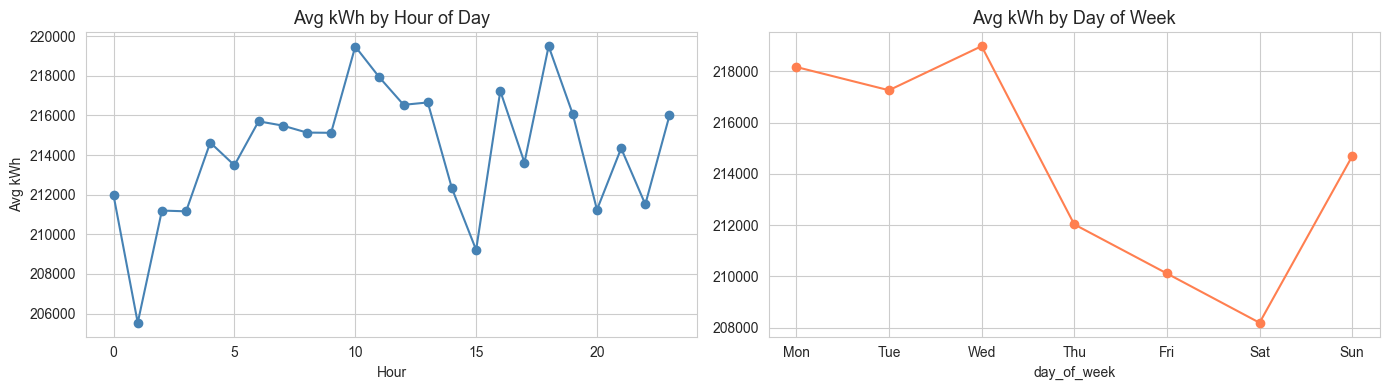

In [12]:
# Hourly & weekly patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

feat_df.groupby('hour_of_day')['total_kwh'].mean().plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Avg kWh by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg kWh')

days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
feat_df.groupby('day_of_week')['total_kwh'].mean().plot(ax=axes[1], marker='o', color='coral')
axes[1].set_title('Avg kWh by Day of Week')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(days)

plt.tight_layout()
plt.show()

In [13]:
feat_df.columns

Index(['rtc_timestamp', 'total_kwh', 'consumption_kwh', 'temperature',
       'humidity', 'precipitation', 'hour_of_day', 'day_of_week', 'month',
       'year', 'is_weekend', 'rolling_max_6', 'rolling_min_6',
       'rolling_range_6', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
       'mon_sin', 'mon_cos', 'kwh_lag_1', 'kwh_lag_2', 'kwh_lag_3',
       'kwh_lag_6', 'kwh_lag_12', 'kwh_lag_24', 'target_diff',
       'kwh_roll_std_3', 'kwh_roll_std_6', 'kwh_roll_std_24', 'diff_2',
       'temperature_lag_1', 'temperature_lag_24', 'temperature_roll_mean_24',
       'humidity_lag_1', 'humidity_lag_24', 'humidity_roll_mean_24',
       'precipitation_lag_1', 'precipitation_lag_24',
       'precipitation_roll_mean_24'],
      dtype='str')

## 5. Train / Test Split

In [14]:
TARGET = 'consumption_kwh'

EXCLUDED = {
    'rtc_timestamp', 'consumption_kwh', "year", "is_weekend", "total_kwh",
    # raw temporal cols — cyclical encodings (sin/cos) are used instead
    'hour_of_day', 'day_of_week', 'month',
    # 'year' is kept as a numeric trend feature (limited extrapolation power,
    # but useful for capturing slow demand growth across years)
    'kwh_roll_mean_3', 'kwh_roll_mean_6', 'kwh_roll_mean_24'
}

model_features = [c for c in feat_df.columns if c not in EXCLUDED]

# Chronological 80/20 split
split_idx = int(len(feat_df) * 0.8)
train_df  = feat_df.iloc[:split_idx].copy()
test_df   = feat_df.iloc[split_idx:].copy()

X_train = train_df[model_features]
y_train = train_df[TARGET]
X_test  = test_df[model_features]
y_test  = test_df[TARGET]

print(f"Train: {train_df['rtc_timestamp'].min()} → {train_df['rtc_timestamp'].max()} | {len(train_df):,} rows")
print(f"Test:  {test_df['rtc_timestamp'].min()} → {test_df['rtc_timestamp'].max()} | {len(test_df):,} rows")
print(f"Features: {len(model_features)}")

Train: 2024-10-17 08:00:00 → 2025-12-17 06:00:00 | 6,124 rows
Test:  2025-12-17 09:00:00 → 2026-04-10 08:00:00 | 1,531 rows
Features: 32


In [ ]:
X_train.nunique().sort_values()

In [15]:
y_train.describe()

count    6124.000000
mean       24.387956
std         9.200388
min         0.000000
25%        19.761897
50%        24.498452
75%        30.313618
max        55.066881
Name: consumption_kwh, dtype: float64

## 6. XGBoost Model — Short-term Forecasting

In [16]:
# explicitly define which columns go into the model
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_features

['temperature',
 'humidity',
 'precipitation',
 'rolling_max_6',
 'rolling_min_6',
 'rolling_range_6',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos',
 'mon_sin',
 'mon_cos',
 'kwh_lag_1',
 'kwh_lag_2',
 'kwh_lag_3',
 'kwh_lag_6',
 'kwh_lag_12',
 'kwh_lag_24',
 'target_diff',
 'kwh_roll_std_3',
 'kwh_roll_std_6',
 'kwh_roll_std_24',
 'diff_2',
 'temperature_lag_1',
 'temperature_lag_24',
 'temperature_roll_mean_24',
 'humidity_lag_1',
 'humidity_lag_24',
 'humidity_roll_mean_24',
 'precipitation_lag_1',
 'precipitation_lag_24',
 'precipitation_roll_mean_24']

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))]), numeric_features)
    ],
    remainder='drop' # Drops unused columns
)

xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=800,
        max_depth=8,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
    ))
])

xgb_model.fit(X_train, y_train)
print('XGBoost training complete')

XGBoost training complete


In [18]:
# Predictions
delta_pred = xgb_model.predict(X_test)
y_pred = X_test['kwh_lag_1'].values + delta_pred
y_pred = pd.DataFrame(y_pred, columns=['consumption_kwh'], index=X_test.index)
y_pred.head()

,consumption_kwh
6124,61.603784
6125,62.363323
6126,43.515396
6127,29.030269
6128,39.576764


In [19]:
# Metrics
def regression_metrics(actual: pd.DataFrame, predicted: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in actual.columns:
        mae = mean_absolute_error(actual[col], predicted[col])
        rmse = root_mean_squared_error(actual[col], predicted[col])
        mape = np.mean(np.abs((actual[col] - predicted[col]) / np.clip(actual[col], 1e-6, None))) * 100
        rows.append({'target': col, 'MAE': mae, 'RMSE': rmse, 'MAPE_pct': mape})
    return pd.DataFrame(rows).sort_values('RMSE')

y_test_actual = test_df['consumption_kwh'].loc[X_test.index]
metrics_df = regression_metrics(y_test_actual.to_frame(), y_pred)
metrics_df

,target,MAE,RMSE,MAPE_pct
0,consumption_kwh,21.729475,23.389216,1.597479e+07


## 7. Plots — Training, Testing, Residuals

In [20]:
# Reconstruct predictions for plotting
# Direct target — no reconstruction needed
y_train_reconstructed = train_df['consumption_kwh'].values

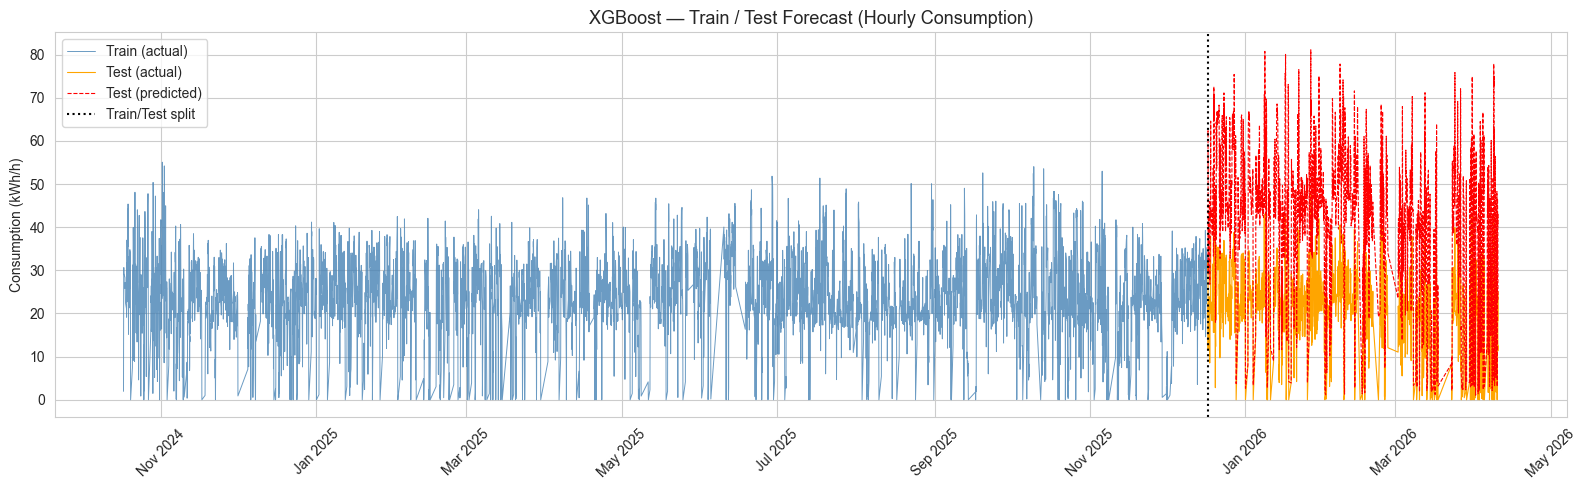

In [21]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train_df['rtc_timestamp'], y_train_reconstructed,          # ← reconstructed, not y_train
        label='Train (actual)', color='steelblue', linewidth=0.7, alpha=0.8)
ax.plot(test_df['rtc_timestamp'], y_test_actual.values,
        label='Test (actual)', color='orange', linewidth=0.8)
ax.plot(test_df['rtc_timestamp'], y_pred['consumption_kwh'].values,
        label='Test (predicted)', color='red', linewidth=0.8, linestyle='--')
ax.axvline(test_df['rtc_timestamp'].iloc[0], color='black', linestyle=':', linewidth=1.5, label='Train/Test split')
ax.set_title('XGBoost — Train / Test Forecast (Hourly Consumption)')
ax.set_ylabel('Consumption (kWh/h)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

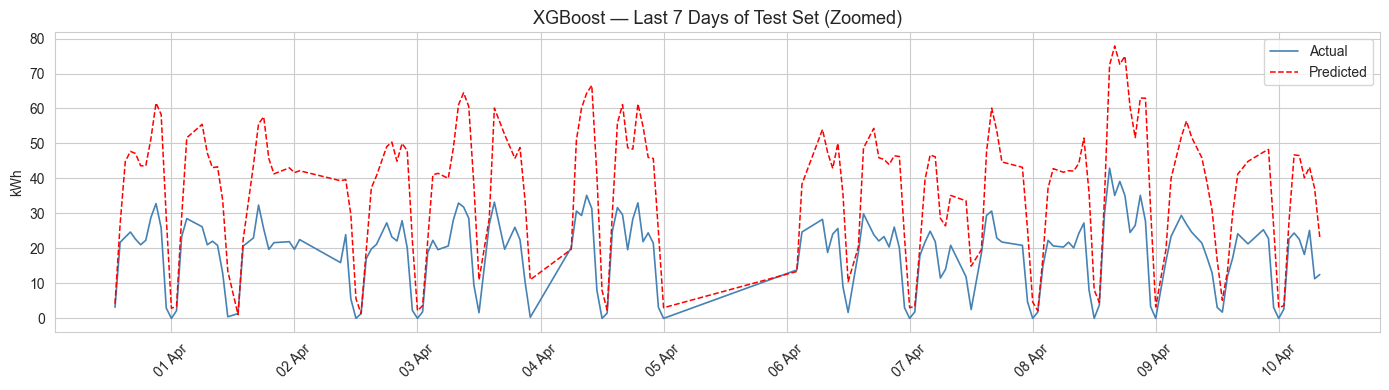

In [22]:
# Zoom into last 7 days of test
last7 = test_df.tail(24 * 7)   # 24 steps/day for 1h intervals, not 96
pred_last7 = y_pred['consumption_kwh'].iloc[-len(last7):]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(last7['rtc_timestamp'], last7['consumption_kwh'],      
        label='Actual', color='steelblue', linewidth=1.2)
ax.plot(last7['rtc_timestamp'], pred_last7.values,      
        label='Predicted', color='red', linewidth=1.1, linestyle='--')
ax.set_title('XGBoost — Last 7 Days of Test Set (Zoomed)')
ax.set_ylabel('kWh')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

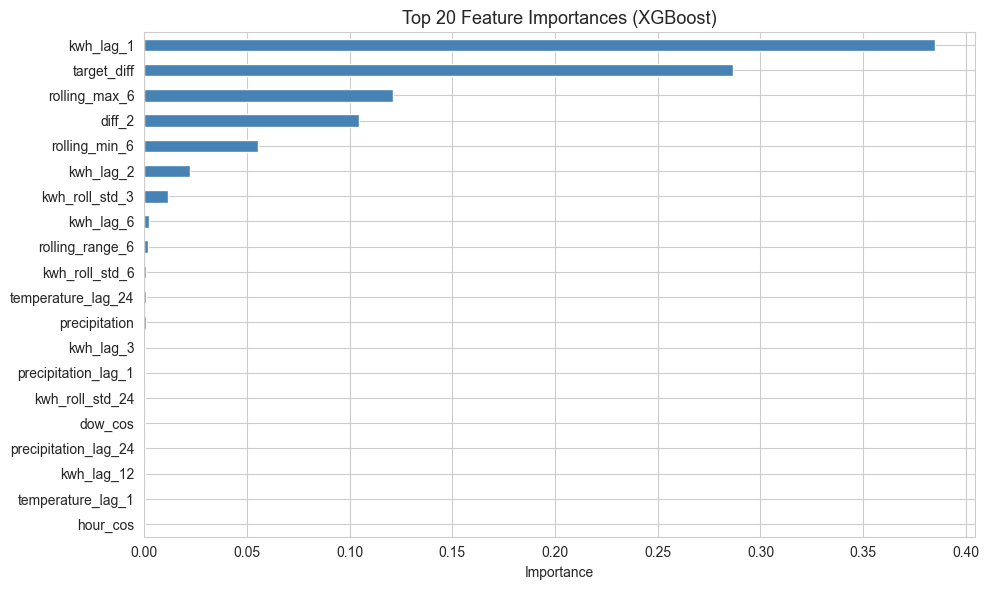

In [23]:
# Feature Importance
booster = xgb_model.named_steps['model']
feat_imp = pd.Series(booster.feature_importances_, index=model_features)
top20 = feat_imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Feature Importances (XGBoost)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 8. Anomaly Detection

In [25]:
results = test_df[['rtc_timestamp', 'consumption_kwh']].copy()
results['predicted'] = y_pred['consumption_kwh'].values        # y_pred is a DataFrame
results['residual'] = results['consumption_kwh'] - results['predicted']
resid_std = results['residual'].std()
results['z_score'] = results['residual'] / resid_std

# Isolation Forest on residuals
iso = IsolationForest(n_estimators=200, contamination=0.03, random_state=42)
results['iso_flag']  = iso.fit_predict(results[['residual']])
results['iso_score'] = iso.decision_function(results[['residual']])

# Rule-based: |z| > 3
results['rule_flag'] = (results['z_score'].abs() > 3).astype(int)
results['anomaly']   = ((results['iso_flag'] == -1) | (results['rule_flag'] == 1)).astype(int)
results['severity']  = results['z_score'].abs().round(3)

anomalies = results[results['anomaly'] == 1].sort_values('severity', ascending=False)
print(f"Anomalies detected: {len(anomalies)} / {len(results)} ({100*len(anomalies)/len(results):.1f}%)")
anomalies.head(10)

Anomalies detected: 459 / 1531 (30.0%)


,rtc_timestamp,consumption_kwh,predicted,residual,z_score,iso_flag,iso_score,rule_flag,anomaly,severity
6715,2026-01-26 19:00:00,30.986419,81.118081,-50.131661,-5.784581,-1,-0.141616,1,1,5.785
6161,2025-12-19 17:00:00,28.635162,72.555652,-43.920490,-5.067888,-1,-0.123667,1,1,5.068
6575,2026-01-16 19:00:00,30.827493,74.196911,-43.369419,-5.004301,-1,-0.119371,1,1,5.004
6469,2026-01-08 19:00:00,26.720897,69.806641,-43.085744,-4.971568,-1,-0.115351,1,1,4.972
7481,2026-03-31 06:00:00,32.045711,74.925394,-42.879683,-4.947791,-1,-0.111353,1,1,4.948
7620,2026-04-08 16:00:00,35.128912,77.874637,-42.745725,-4.932334,-1,-0.109610,1,1,4.932
6780,2026-01-30 00:00:00,32.635171,75.043145,-42.407974,-4.893362,-1,-0.106880,1,1,4.893
6463,2026-01-08 13:00:00,29.196454,70.762172,-41.565718,-4.796176,-1,-0.094513,1,1,4.796
6577,2026-01-16 21:00:00,38.573350,80.059466,-41.486115,-4.786991,-1,-0.092517,1,1,4.787
6898,2026-02-07 07:00:00,37.565422,77.831947,-40.266525,-4.646265,-1,-0.074956,1,1,4.646


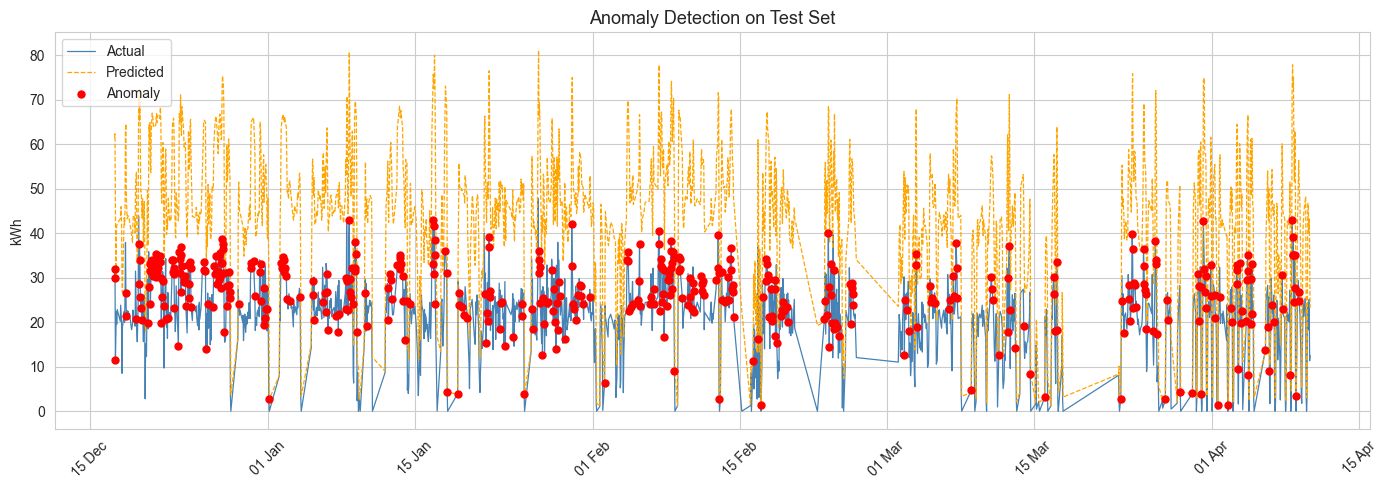

In [27]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(results['rtc_timestamp'], results['consumption_kwh'], label='Actual', linewidth=0.9, color='steelblue')
ax.plot(results['rtc_timestamp'], results['predicted'], label='Predicted', linewidth=0.9, color='orange', linestyle='--')
ax.scatter(anomalies['rtc_timestamp'], anomalies['consumption_kwh'], color='red', s=25, zorder=5, label='Anomaly')
ax.set_title('Anomaly Detection on Test Set')
ax.set_ylabel('kWh')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Save XGBoost Model

In [29]:
import os
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(xgb_model, f"{MODEL_DIR}/xgb_energy_model.pkl")
joblib.dump(model_features, f"{MODEL_DIR}/model_features.pkl")

print('XGBoost model saved.')

XGBoost model saved.


## 10. PENDING FROM HERE: N-HiTS - Long-term Future Forecasting (May 2026)

> **N-HiTS** (Neural Hierarchical Interpolation for Time Series) is designed for long-horizon forecasting.  
> It predicts the full future window in **one shot** — no recursive error accumulation.

In [ ]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS
from neuralforecast.losses.pytorch import MAE

FORECAST_HORIZON = 24 * 31    # 31 days × 24h = 744 steps  (was 96*31 = wrong, 15-min)
INPUT_SIZE = 24 * 14    # look back 2 weeks = 336h    (was 96*14)

nf_df = df[['rtc_timestamp', 'consumption_kwh'] + WEATHER_COLS].copy()
nf_df = nf_df.dropna(subset=['rtc_timestamp', 'consumption_kwh'])
nf_df.loc[nf_df['consumption_kwh'] == 0, 'consumption_kwh'] = np.nan

nf_df = nf_df.rename(columns={'rtc_timestamp': 'ds', 'consumption_kwh': 'y'})
nf_df['unique_id'] = METER_ID
nf_df = nf_df[['unique_id', 'ds', 'y'] + WEATHER_COLS]

print(f"NeuralForecast df shape: {nf_df.shape}")
nf_df.head()

2026-04-23 11:08:45,117	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-04-23 11:08:45,780	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


NeuralForecast df shape: (12366, 6)


,unique_id,ds,y,temperature,humidity,precipitation
0,FUTU0000000004000002,2024-10-16 05:00:00,22.989561,25.1,94,0.0
1,FUTU0000000004000002,2024-10-16 06:00:00,27.715203,26.2,87,0.0
2,FUTU0000000004000002,2024-10-16 07:00:00,17.664545,26.8,86,0.0
3,FUTU0000000004000002,2024-10-16 08:00:00,29.952367,28.2,82,0.0
4,FUTU0000000004000002,2024-10-16 09:00:00,32.767943,30.0,76,0.0


In [41]:
nf_df['y'] = nf_df['y'].interpolate(method='linear')
nf_df = nf_df.dropna(subset=['y'])  # catch any leading NaNs that can't be interpolated

In [42]:
# Train / val split for NeuralForecast (last HORIZON rows as validation)
nf_train = nf_df.iloc[:-FORECAST_HORIZON].copy()
nf_val   = nf_df.iloc[-FORECAST_HORIZON:].copy()

print(f"NF Train: {nf_train['ds'].min()} → {nf_train['ds'].max()}")
print(f"NF Val: {nf_val['ds'].min()} → {nf_val['ds'].max()}")

NF Train: 2024-10-16 05:00:00 → 2026-03-10 08:00:00
NF Val: 2026-03-10 09:00:00 → 2026-04-10 08:00:00


In [43]:
nhits = NHITS(
    h=FORECAST_HORIZON,
    input_size=INPUT_SIZE,
    loss=MAE(),
    max_steps=1000,
    batch_size=32,
    early_stop_patience_steps=0,
    val_check_steps=50,
    scaler_type='standard',
    n_freq_downsample=[24, 4, 1],
    # Weather as historical exogenous: the model sees weather patterns in the
    # lookback window. We use hist_exog (not futr_exog) because reliable
    # weather forecasts are only ~16 days, but our horizon is 31 days.
    hist_exog_list=WEATHER_COLS,
)

nf = NeuralForecast(models=[nhits], freq='h')   
nf.fit(df=nf_train, val_size=FORECAST_HORIZON)
print('N-HiTS training complete')

Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 4.8 M  | train | 0    
---------------------------------------------------------------
4.8 M     Trainable params
0         Non-trainable params
4.8 M     Total params
19.007    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 999: 100%|██████████| 1/1 [00:00<00:00,  5.11it/s, v_num=8, train_loss_step=0.328, train_loss_epoch=0.328, valid_loss=9.650]

`Trainer.fit` stopped: `max_steps=1000` reached.


Epoch 999: 100%|██████████| 1/1 [00:00<00:00,  5.04it/s, v_num=8, train_loss_step=0.328, train_loss_epoch=0.328, valid_loss=9.650]
N-HiTS training complete


In [44]:
# Validate on held-out period
val_preds = nf.predict()
val_preds.head()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 164.44it/s]


,unique_id,ds,NHITS
0,FUTU0000000004000002,2026-03-10 09:00:00,19.529512
1,FUTU0000000004000002,2026-03-10 10:00:00,20.055763
2,FUTU0000000004000002,2026-03-10 11:00:00,20.085247
3,FUTU0000000004000002,2026-03-10 12:00:00,21.143116
4,FUTU0000000004000002,2026-03-10 13:00:00,23.129097


In [45]:
# Validation metrics
merged = nf_val.merge(val_preds[['unique_id', 'ds', 'NHITS']], on=['unique_id', 'ds'], how='inner')

nhits_mae  = mean_absolute_error(merged['y'], merged['NHITS'])
nhits_rmse = root_mean_squared_error(merged['y'], merged['NHITS'])
nhits_mape = np.mean(np.abs((merged['y'] - merged['NHITS']) / np.clip(merged['y'], 1e-6, None))) * 100

print(f"N-HiTS Validation MAE : {nhits_mae:.4f} kWh")
print(f"N-HiTS Validation RMSE : {nhits_rmse:.4f} kWh")
print(f"N-HiTS Validation MAPE : {nhits_mape:.2f}%")

N-HiTS Validation MAE : 9.6166 kWh
N-HiTS Validation RMSE : 11.4212 kWh
N-HiTS Validation MAPE : 391.95%


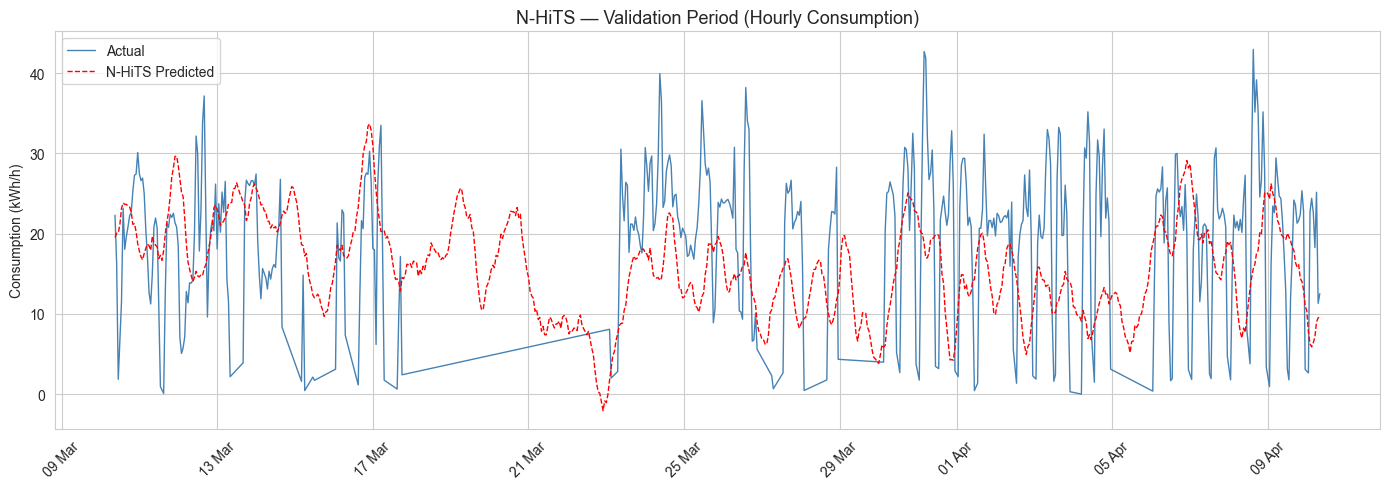

In [46]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(merged['ds'], merged['y'], label='Actual', color='steelblue', linewidth=1)
ax.plot(merged['ds'], merged['NHITS'], label='N-HiTS Predicted', color='red', linewidth=1, linestyle='--')
ax.set_title('N-HiTS — Validation Period (Hourly Consumption)')
ax.set_ylabel('Consumption (kWh/h)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Forecast Future — May 2026

In [47]:
# Retrain on FULL data before forecasting future
nf_full = NeuralForecast(models=[nhits], freq='h')  
nf_full.fit(df=nf_df)

future_forecast = nf_full.predict()
future_forecast = future_forecast.rename(columns={'NHITS': 'forecast_kwh'})
future_forecast['forecast_kwh'] = future_forecast['forecast_kwh'].clip(lower=0)

print(f"Future forecast: {future_forecast['ds'].min()} → {future_forecast['ds'].max()}")
future_forecast.head()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 4.8 M  | train | 0    
---------------------------------------------------------------
4.8 M     Trainable params
0         Non-trainable params
4.8 M     Total params
19.007    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 999: 100%|██████████| 1/1 [00:00<00:00,  5.40it/s, v_num=10, train_loss_step=0.353, train_loss_epoch=0.353]

`Trainer.fit` stopped: `max_steps=1000` reached.


Epoch 999: 100%|██████████| 1/1 [00:00<00:00,  5.34it/s, v_num=10, train_loss_step=0.353, train_loss_epoch=0.353]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 142.62it/s]
Future forecast: 2026-04-10 09:00:00 → 2026-05-11 08:00:00


,unique_id,ds,forecast_kwh
0,FUTU0000000004000002,2026-04-10 09:00:00,11.265225
1,FUTU0000000004000002,2026-04-10 10:00:00,11.064669
2,FUTU0000000004000002,2026-04-10 11:00:00,11.855876
3,FUTU0000000004000002,2026-04-10 12:00:00,11.036399
4,FUTU0000000004000002,2026-04-10 13:00:00,11.165290


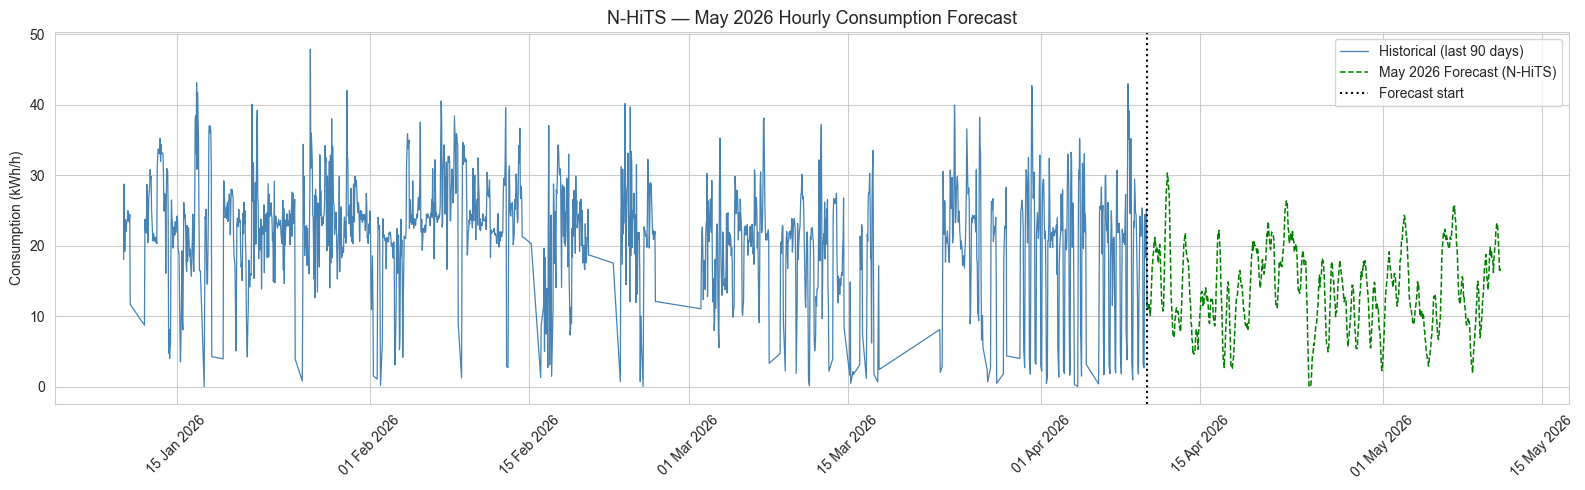

In [48]:
# Plot: history + future forecast
last_90d = nf_df[nf_df['ds'] >= nf_df['ds'].max() - pd.Timedelta(days=90)]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(last_90d['ds'], last_90d['y'], label='Historical (last 90 days)', color='steelblue', linewidth=0.9)
ax.plot(future_forecast['ds'], future_forecast['forecast_kwh'],
        label='May 2026 Forecast (N-HiTS)', color='green', linewidth=1.1, linestyle='--')
ax.axvline(nf_df['ds'].max(), color='black', linewidth=1.5, linestyle=':', label='Forecast start')
ax.set_title('N-HiTS — May 2026 Hourly Consumption Forecast')
ax.set_ylabel('Consumption (kWh/h)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

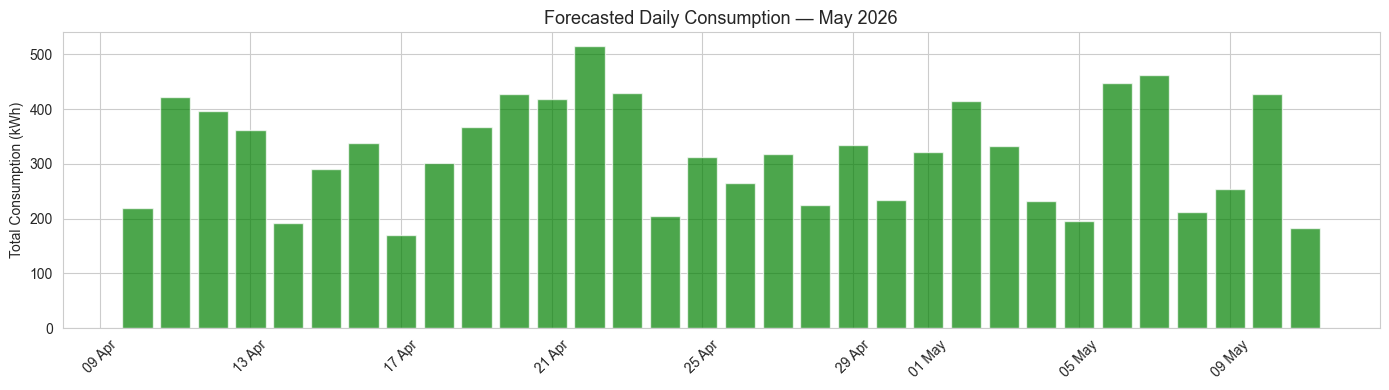

Total forecasted energy for May 2026: 10231.64 kWh


In [49]:
# Daily aggregated forecast for May
daily_forecast = (
    future_forecast.set_index('ds')['forecast_kwh']
    .resample('D').sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(daily_forecast['ds'], daily_forecast['forecast_kwh'], color='green', alpha=0.7, width=0.8)
ax.set_title('Forecasted Daily Consumption — May 2026')
ax.set_ylabel('Total Consumption (kWh)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Total forecasted energy for May 2026: {daily_forecast['forecast_kwh'].sum():.2f} kWh")

In [50]:
# Compare model summaries
summary = pd.DataFrame([
    {'Model': 'XGBoost (1-step)', 'MAE': metrics_df["MAE"], 'RMSE': metrics_df["RMSE"], 'MAPE%': metrics_df["MAPE_pct"],
     'Use case': 'Next 1h to 1-2 days'},           
    {'Model': 'N-HiTS', 'MAE': nhits_mae, 'RMSE': nhits_rmse, 'MAPE%': nhits_mape,
     'Use case': 'Next 1 month (May 2026)'}
])
summary.round(4)

,Model,MAE,RMSE,MAPE%,Use case
0,XGBoost (1-step),"0 21.729475 Name: MAE, dtype: float64","0 23.389216 Name: RMSE, dtype: float64","0 1.597479e+07 Name: MAPE_pct, dtype: float64",Next 1h to 1-2 days
1,N-HiTS,9.616583,11.421216,391.950237,Next 1 month (May 2026)


In [51]:
# Save future forecast
future_forecast.to_csv(f"{MODEL_DIR}/may_2026_forecast.csv", index=False)
nf_full.save(f"{MODEL_DIR}/nhits_model", overwrite=True)
print('N-HiTS model and forecast saved.')

N-HiTS model and forecast saved.


## 12. XGBoost Recursive - Short-term Future (1–2 days ahead)

> Use this for next-day operations where accuracy matters more than horizon length.

In [ ]:
def forecast_recursive(model, history_df: pd.DataFrame, steps: int = 24,
                       future_weather: pd.DataFrame | None = None) -> pd.DataFrame:
    """
    Recursive 1-step-at-a-time XGBoost forecasting.

    Parameters
    ----------
    model         : fitted pipeline that predicts `target_diff` (Δ kWh).
    history_df    : continuous hourly DataFrame with at least
                    ['rtc_timestamp', 'total_kwh'] and any weather cols.
    steps         : number of 1-hour steps to forecast.
    future_weather: optional DataFrame with ['rtc_timestamp', <weather cols>]
                    covering the forecast horizon. If None, real forecast
                    weather is fetched from Open-Meteo for Ahmedabad.
    """
    base_cols = ['rtc_timestamp', 'total_kwh']
    weather_present = [c for c in WEATHER_COLS if c in history_df.columns]
    history = history_df[base_cols + weather_present].copy().reset_index(drop=True)

    last_ts = history['rtc_timestamp'].iloc[-1]
    future_ts = pd.date_range(last_ts + pd.Timedelta(hours=1), periods=steps, freq='1h')

    # Fetch real weather forecast from Open-Meteo if not supplied
    if weather_present:
        if future_weather is None:
            future_weather = fetch_forecast_weather(future_ts[0], steps)
        future_weather = future_weather.set_index('rtc_timestamp')

    preds = []

    for next_ts in future_ts:
        row = {}

        # Temporal features (must match build_features)
        row['hour_sin']   = np.sin(2 * np.pi * next_ts.hour / 24)
        row['hour_cos']   = np.cos(2 * np.pi * next_ts.hour / 24)
        row['dow_sin']    = np.sin(2 * np.pi * next_ts.dayofweek / 7)
        row['dow_cos']    = np.cos(2 * np.pi * next_ts.dayofweek / 7)
        row['mon_sin']    = np.sin(2 * np.pi * next_ts.month / 12)
        row['mon_cos']    = np.cos(2 * np.pi * next_ts.month / 12)
        row['is_weekend'] = int(next_ts.dayofweek >= 5)
        row['year']       = next_ts.year

        # kWh lag features
        for lag in [1, 2, 3, 6, 12, 24]:
            row[f'kwh_lag_{lag}'] = (
                history['total_kwh'].iloc[-lag] if lag <= len(history) else np.nan
            )

        # kWh rolling stats / windowed range
        last6 = history['total_kwh'].iloc[-6:]
        row['rolling_max_6']   = last6.max()
        row['rolling_min_6']   = last6.min()
        row['rolling_range_6'] = row['rolling_max_6'] - row['rolling_min_6']
        for w in [3, 6, 24]:
            row[f'kwh_roll_std_{w}'] = history['total_kwh'].iloc[-w:].std()
        row['diff_2'] = history['total_kwh'].iloc[-1] - history['total_kwh'].iloc[-3]

        # Weather features (current + lag + 24h rolling mean)
        for col in weather_present:
            cur_val = float(future_weather.loc[next_ts, col])
            row[col] = cur_val
            row[f'{col}_lag_1']  = history[col].iloc[-1]
            row[f'{col}_lag_24'] = (
                history[col].iloc[-24] if 24 <= len(history) else history[col].iloc[0]
            )
            recent = history[col].iloc[-23:].tolist() + [cur_val]
            row[f'{col}_roll_mean_24'] = float(np.mean(recent))

        # Predict Δ kWh and reconstruct absolute kWh
        X_row     = pd.DataFrame([row]).reindex(columns=model_features)
        delta     = float(model.predict(X_row)[0])
        last_kwh  = float(history['total_kwh'].iloc[-1])
        pred_kwh  = max(last_kwh + delta, 0.0)

        preds.append({'rtc_timestamp': next_ts, 'total_kwh': pred_kwh})

        # Append to rolling history for next step's lag/rolling
        new_row = {'rtc_timestamp': next_ts, 'total_kwh': pred_kwh}
        for col in weather_present:
            new_row[col] = float(future_weather.loc[next_ts, col])
        history = pd.concat([history, pd.DataFrame([new_row])], ignore_index=True)

    return pd.DataFrame(preds)


# Forecast next 48 hours (fetches real weather forecast from Open-Meteo)
next_48h = forecast_recursive(xgb_model, df, steps=24 * 2)  

fig, ax = plt.subplots(figsize=(14, 4))
last_3d = feat_df.tail(24 * 3)                                    
ax.plot(last_3d['rtc_timestamp'], last_3d['total_kwh'], label='Historical (last 3 days)', color='steelblue')
ax.plot(next_48h['rtc_timestamp'], next_48h['total_kwh'], label='XGBoost Next 48h', color='red', linestyle='--')
ax.axvline(feat_df['rtc_timestamp'].iloc[-1], color='black', linestyle=':', linewidth=1.5)
ax.set_title('XGBoost Recursive — Next 48 Hours')
ax.set_ylabel('kWh')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()